In [43]:
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split 

from torch.utils.data import TensorDataset
from torch.utils.data import DataLoader

import numpy as np
import torch
import matplotlib.pyplot as plt

## Построение многослойного персептрона

In [69]:
iris = load_iris()
X = iris['data']
y = iris['target']
 
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=.3, random_state=1, stratify=y)

In [71]:
f"X: {(X_train.shape, X_test.shape)}, y: {(y_train.shape, y_test.shape)}"

'X: ((105, 4), (45, 4)), y: ((105,), (45,))'

In [73]:
# стандартизируем и переводим в тензор
X_train_norm = (X_train - np.mean(X_train)) / np.std(X_train)
X_train_norm = torch.from_numpy(X_train_norm).float()
y_train = torch.from_numpy(y_train) 

train_ds = TensorDataset(X_train_norm, y_train)

torch.manual_seed(1)
batch_size = 2
train_dl = DataLoader(train_ds, batch_size, shuffle=True)

In [75]:
class Model(torch.nn.Module):
    """
        Применяем слой Linear, который также известен как полносвязный, или плотный: f(w * x + b), 
        где x - тензор, содержащий входные признаки; w и b - матрица весов и вектор смещения, а 
        f - функция активации

        Каждый слой получает входные данные от предыдущего слоя, следовательно его размерность (ранг и форма)
        постоянна и строго определена.

        Мы использовали сигмоидную функцию активации для первого слоя и активацию softmax для последнего(выходного) слоя.
        Активация softmax в последнем слое служит для многоклассовой классификации.

        Используем функцию потерь на основе перекрестной энтропии и оптимизатор Adam
    """
    
    def __init__(self, input_size, hidden_size, output_size):
        super().__init__()
        self.layer1 = torch.nn.Linear(input_size, hidden_size)  
        self.layer2 = torch.nn.Linear(hidden_size, output_size)  

    def forward(self, x):
        x = self.layer1(x)
        x = torch.nn.Sigmoid()(x)
        x = self.layer2(x)
        x = torch.nn.Softmax(dim=1)(x)
        return x
    
input_size = X_train_norm.shape[1]
hidden_size = 16
output_size = 3
 
model = Model(input_size, hidden_size, output_size)

learning_rate = 0.001

loss_fn = torch.nn.CrossEntropyLoss()
 
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)

In [77]:
num_epochs = 100
loss_hist = [0] * num_epochs
accuracy_hist = [0] * num_epochs

for epoch in range(num_epochs):

    for x_batch, y_batch in train_dl:
        pred = model(x_batch)
        loss = loss_fn(pred, y_batch.long())
        loss.backward()
        optimizer.step()
        optimizer.zero_grad()

        # Списки loss_hist и accuracy_hist сохраняют потери и точность при обучении модели после каждой эпохи.
        loss_hist[epoch] += loss.item()*y_batch.size(0)
        is_correct = (torch.argmax(pred, dim=1) == y_batch).float()
        accuracy_hist[epoch] += is_correct.sum()
        
    loss_hist[epoch] /= len(train_dl.dataset)
    accuracy_hist[epoch] /= len(train_dl.dataset)

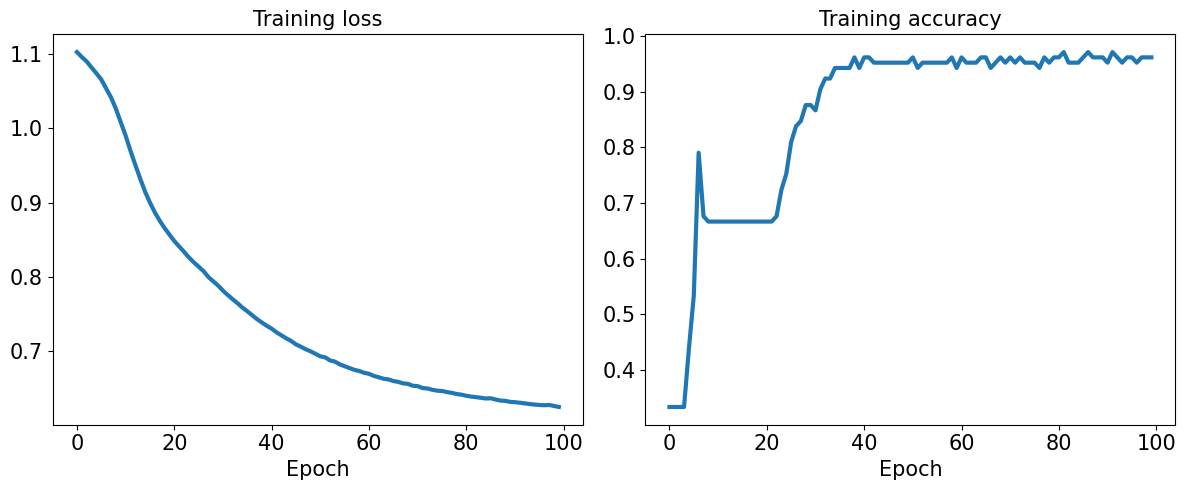

In [78]:
fig = plt.figure(figsize=(12, 5))
ax = fig.add_subplot(1, 2, 1)
ax.plot(loss_hist, lw=3)
ax.set_title('Training loss', size=15)
ax.set_xlabel('Epoch', size=15)
ax.tick_params(axis='both', which='major', labelsize=15)

ax = fig.add_subplot(1, 2, 2)
ax.plot(accuracy_hist, lw=3)
ax.set_title('Training accuracy', size=15)
ax.set_xlabel('Epoch', size=15)
ax.tick_params(axis='both', which='major', labelsize=15)
plt.tight_layout()
plt.show()

## Оценка обученной модели на тестовом наборе данных

In [79]:
# оценим точность на тестовом
X_test_norm = (X_test - np.mean(X_train)) / np.std(X_train)
X_test_norm = torch.from_numpy(X_test_norm).float()
y_test = torch.from_numpy(y_test) 
pred_test = model(X_test_norm)

correct = (torch.argmax(pred_test, dim=1) == y_test).float()
accuracy = correct.mean()
 
print(f'Test Acc.: {accuracy:.4f}')

Test Acc.: 0.9778


## Сохранение и повторная загрузка обученной модели

In [89]:
path = "iris_classifier.pt"
torch.save(model, path)

Вызов save сохранит как архитектуру модели, так и все обученные параметры. Как правило pt или pth

In [96]:
# загрузим модель
model_new = torch.load(path, weights_only=False)

In [98]:
# проверим архитектуру
model_new.eval()

Model(
  (layer1): Linear(in_features=4, out_features=16, bias=True)
  (layer2): Linear(in_features=16, out_features=3, bias=True)
)